# Range Tau Visualization
## Model Testing and Visualization for AxialTransformer, PoolingMLP and TabPFNPooling

This notebook provides comprehensive testing and visualization for the models trained on the Lennon7 range tau dataset:
- **AxialTransformer** (axial_transformer_raw_lennon7)
- **PoolingMLP** (mlp_raw_lennon7)
- **TabPFNPooling** (tabpfn_pooling_raw_lennon7)

All models are trained to predict treatment effects (tau) in the range [-5, 5] using 7 instruments.

In [52]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import os
from typing import Dict, Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [53]:
# Import model classes
import sys

from src.model.axial_transformer import AxialTransformer
from src.model.pooling_mlp import PoolingMLP
from src.model.tabpfn_pooling import TabPFNPoolingRegressor

print("Model classes imported successfully!")

Model classes imported successfully!


## Model Configuration and Path Setup

In [54]:
# Model configuration parameters
axial_transformer_config = {
    'n_blocks': 4,
    'n_heads': 4,
    'd_model': 64,
    'd_hidden': 256,
    'feature_group_ids': [0, 1] + [2] * 7,  # T=0, Y=1, Z1-Z7=2
    'num_feature_groups': 3,
    'lr': 1e-3,
    'weight_decay': 1e-4
}

pooling_mlp_config = {
    'input_channels': 9,  # T + Y + 7*Z
    'hidden_channels': 256,
    'depth': 2,
    'num_classes': 1,
    'lr': 1e-3,
    'weight_decay': 1e-4
}

tabpfn_pooling_config = {
    'n_estimators': 1,
    'head_hidden_dim': 128,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'cache_dir': './data/tabpfn_embed_cache',
    'device': 'auto'
}

# Data and checkpoint paths
data_dir = 'data/lennon7-range-tau-10k'
checkpoint_dir = 'checkpoints/linear'

print(f"Data directory: {data_dir}")
print(f"Checkpoint directory: {checkpoint_dir}")
print(f"AxialTransformer config: {axial_transformer_config}")
print(f"PoolingMLP config: {pooling_mlp_config}")
print(f"TabPFNPooling config: {tabpfn_pooling_config}")

Data directory: data/lennon7-range-tau-10k
Checkpoint directory: checkpoints/linear
AxialTransformer config: {'n_blocks': 4, 'n_heads': 4, 'd_model': 64, 'd_hidden': 256, 'feature_group_ids': [0, 1, 2, 2, 2, 2, 2, 2, 2], 'num_feature_groups': 3, 'lr': 0.001, 'weight_decay': 0.0001}
PoolingMLP config: {'input_channels': 9, 'hidden_channels': 256, 'depth': 2, 'num_classes': 1, 'lr': 0.001, 'weight_decay': 0.0001}
TabPFNPooling config: {'n_estimators': 1, 'head_hidden_dim': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'cache_dir': './data/tabpfn_embed_cache', 'device': 'auto'}


## Model Loading Utility Functions

In [55]:
def find_latest_checkpoint(checkpoint_dir: str, model_prefix: str) -> str:
    """
    Find the latest checkpoint file for the specified model
    """
    pattern = os.path.join(checkpoint_dir, f"*{model_prefix}*", "**", "*.ckpt")
    checkpoints = glob.glob(pattern, recursive=True)
    
    if not checkpoints:
        print(f"No checkpoint found for {model_prefix}, search pattern: {pattern}")
        return None
    
    # Sort by modification time, return the latest
    latest_checkpoint = max(checkpoints, key=os.path.getmtime)
    print(f"Found {model_prefix} checkpoint: {latest_checkpoint}")
    return latest_checkpoint

def load_model_from_checkpoint(model_class, config: Dict, checkpoint_path: str):
    """
    Load model from checkpoint
    """
    try:
        model = model_class.load_from_checkpoint(checkpoint_path, **config)
        model.eval()
        print(f"Successfully loaded model from checkpoint: {model_class.__name__}")
        return model
    except Exception as e:
        print(f"Checkpoint loading failed: {e}")
        print(f"Creating new model instance: {model_class.__name__}")
        model = model_class(**config)
        model.eval()
        return model

def load_models():
    """
    Load models
    """
    # Try to load pre-trained models
    axial_checkpoint = find_latest_checkpoint(checkpoint_dir, "axial_transformer")
    mlp_checkpoint = find_latest_checkpoint(checkpoint_dir, "pooling_mlp")
    
    # Load AxialTransformer
    if axial_checkpoint:
        axial_model = load_model_from_checkpoint(AxialTransformer, axial_transformer_config, axial_checkpoint)
    else:
        axial_model = AxialTransformer(**axial_transformer_config)
        axial_model.eval()
        print("Using untrained AxialTransformer model")
    
    # Load PoolingMLP
    if mlp_checkpoint:
        mlp_model = load_model_from_checkpoint(PoolingMLP, pooling_mlp_config, mlp_checkpoint)
    else:
        mlp_model = PoolingMLP(**pooling_mlp_config)
        mlp_model.eval()
        print("Using untrained PoolingMLP model")
    
    # Initialize TabPFNPooling (no checkpoint loading)
    tabpfn_pooling_model = TabPFNPoolingRegressor(**tabpfn_pooling_config)
    tabpfn_pooling_model.eval()
    print("Initialized TabPFNPoolingRegressor")
    
    return axial_model, mlp_model, tabpfn_pooling_model

print("Model loading utility functions defined")

Model loading utility functions defined


In [56]:
# Load models
axial_model, mlp_model, tabpfn_model = load_models()
print("\nModel loading completed")

Found axial_transformer checkpoint: checkpoints/linear/axial_transformer_raw_lennon7_bs128_lr0.001_wd0.0001_eps35/ckpts/exp_name=axial_transformer_raw_lennon7_bs128_lr0.001_wd0.0001_eps35-val_loss=0.0557.ckpt
Found pooling_mlp checkpoint: checkpoints/linear/pooling_mlp_raw_lennon7_bs128_lr0.001_wd0.0001_eps35/ckpts/exp_name=pooling_mlp_raw_lennon7_bs128_lr0.001_wd0.0001_eps35-val_loss=0.0051.ckpt
Successfully loaded model from checkpoint: AxialTransformer
Successfully loaded model from checkpoint: PoolingMLP
Initialized TabPFNPoolingRegressor

Model loading completed


## Data Loading and Preprocessing

In [57]:
def generate_synthetic_data(n_samples: int = 100) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generate synthetic test data for demonstration
    Simulates Lennon7 data structure: T, Y, Z1-Z7 (9 features total)
    """
    print(f"Generating {n_samples} synthetic test samples")
    
    # Generate true treatment effects tau
    true_tau = (torch.rand(n_samples) * 10.0) - 5.0
    
    # Generate instrumental variables Z (7 instruments)
    Z = torch.randn(n_samples, 1000, 7)
    
    # Generate treatment variable T, influenced by instruments
    Z_effect = torch.sum(Z, dim=-1, keepdim=True) * 0.1  # (n_samples, 1000, 1)
    T = Z_effect + torch.randn(n_samples, 1000, 1) * 0.5
    
    # Generate outcome variable Y, influenced by treatment and treatment effect
    tau_expanded = true_tau.unsqueeze(1).unsqueeze(2).expand(-1, 1000, 1)  # (n_samples, 1000, 1)
    Y = tau_expanded * T + torch.randn(n_samples, 1000, 1) * 0.5
    
    # Combine all features [T, Y, Z1-Z7]
    X = torch.cat([T, Y, Z], dim=-1)  # (n_samples, 1000, 9)
    
    print(f"Synthetic data generated: X={X.shape}, tau={true_tau.shape}")
    print(f"   True tau range: [{true_tau.min():.2f}, {true_tau.max():.2f}]")
    
    return X, true_tau
from tqdm import tqdm
def load_test_data(data_dir: str, n_samples: int = 100) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Load test data, generate synthetic data if real data doesn't exist
    """
    try:
        # Look for test data files
        test_files = glob.glob(os.path.join(data_dir, "test", "uid=*.parquet"))
        X_test = []
        y_true = []
        
        for test_file in tqdm(test_files, desc="Loading test data"):
            df = pd.read_parquet(test_file)
            
            # Extract tau from filename
            import re
            filename = os.path.basename(test_file)
            tau_match = re.search(r'treatment_effect=([+-]?\d+\.?\d*)', filename)
            
            X_test.append(torch.tensor(df.values, dtype=torch.float32))
            y_true.append(torch.tensor(float(tau_match.group(1)), dtype=torch.float32))
        
        return torch.stack(X_test), torch.tensor(y_true)
               

    except Exception as e:
        print(f"Data loading error: {e}, generating synthetic data")
        return generate_synthetic_data(n_samples)

print("Data loading utility functions defined")

Data loading utility functions defined


In [58]:
# Load test data
X_test, y_true = load_test_data(data_dir, n_samples=200)

print(f"\nTest data statistics:")
print(f"   Input shape: {X_test.shape}")
print(f"   Target shape: {y_true.shape}")
print(f"   True tau range: [{y_true.min():.2f}, {y_true.max():.2f}]")
print(f"   True tau mean: {y_true.mean():.2f} ± {y_true.std():.2f}")

Loading test data: 100%|███████████████████████████████████████████| 1000/1000 [00:01<00:00, 530.41it/s]


Test data statistics:
   Input shape: torch.Size([1000, 1000, 9])
   Target shape: torch.Size([1000])
   True tau range: [-5.00, 4.99]
   True tau mean: -0.08 ± 2.85


## Model Prediction and Evaluation

In [59]:
def evaluate_model(model, X_test: torch.Tensor, y_true: torch.Tensor, model_name: str) -> Dict:
    """
    Evaluate model performance
    """
    print(f"\nEvaluating {model_name}...")
    
    with torch.no_grad():
        try:
            # Model prediction
            y_pred = model(X_test).squeeze()
            
            # Ensure predictions are 1D
            if y_pred.dim() > 1:
                y_pred = y_pred.flatten()
            
            # Handle length mismatch
            if len(y_pred) != len(y_true):
                min_len = min(len(y_pred), len(y_true))
                y_pred = y_pred[:min_len]
                y_true_eval = y_true[:min_len]
            else:
                y_true_eval = y_true
                
        except Exception as e:
            print(f"Model prediction failed: {e}")
            # Generate random predictions as fallback
            y_pred = torch.randn_like(y_true)
            y_true_eval = y_true
    
    # Calculate evaluation metrics
    mse = torch.mean((y_pred - y_true_eval) ** 2).item()
    mae = torch.mean(torch.abs(y_pred - y_true_eval)).item()
    rmse = np.sqrt(mse)
    
    # Calculate correlation coefficient
    y_pred_np = y_pred.numpy()
    y_true_np = y_true_eval.numpy()
    
    try:
        correlation = np.corrcoef(y_pred_np, y_true_np)[0, 1]
        if np.isnan(correlation):
            correlation = 0.0
    except:
        correlation = 0.0
    
    results = {
        'model_name': model_name,
        'predictions': y_pred_np,
        'true_values': y_true_np,
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'correlation': correlation
    }
    
    print(f"{model_name} evaluation results:")
    print(f"   MSE: {mse:.4f}")
    print(f"   MAE: {mae:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   Correlation: {correlation:.4f}")
    print(f"   Prediction range: [{y_pred_np.min():.2f}, {y_pred_np.max():.2f}]")
    
    return results

print("Model evaluation function defined")

Model evaluation function defined


In [60]:
# Evaluate models
axial_results = evaluate_model(axial_model, X_test, y_true, "AxialTransformer")
mlp_results = evaluate_model(mlp_model, X_test, y_true, "PoolingMLP")
tabpfn_results = evaluate_model(tabpfn_model, X_test, y_true, "TabPFNPooling")

print("\n" + "="*60)
print("Model evaluation completed")
print("="*60)


Evaluating AxialTransformer...
AxialTransformer evaluation results:
   MSE: 0.0515
   MAE: 0.1989
   RMSE: 0.2270
   Correlation: 0.9993
   Prediction range: [-5.50, 5.33]

Evaluating PoolingMLP...
PoolingMLP evaluation results:
   MSE: 0.0052
   MAE: 0.0580
   RMSE: 0.0722
   Correlation: 0.9998
   Prediction range: [-5.07, 5.11]

Evaluating TabPFNPooling...
TabPFNPooling evaluation results:
   MSE: 8.1009
   MAE: 2.4432
   RMSE: 2.8462
   Correlation: 0.1703
   Prediction range: [-0.13, -0.09]

Model evaluation completed


## Results Visualization

In [61]:
def plot_predictions_vs_true(results_list: List[Dict]):
    """
    Plot predicted vs true values scatter plot
    """
    fig, axes = plt.subplots(1, len(results_list), figsize=(15, 6))
    if len(results_list) == 1:
        axes = [axes]
    
    for i, results in enumerate(results_list):
        ax = axes[i]
        y_pred = results['predictions']
        y_true = results['true_values']
        
        # Scatter plot
        ax.scatter(y_true, y_pred, alpha=0.6, s=40, color=f'C{i}')
        
        # Perfect prediction line y=x
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='Perfect Prediction')
        
        ax.set_xlabel('True τ Values', fontsize=12)
        ax.set_ylabel('Predicted τ Values', fontsize=12)
        ax.set_title(f'{results["model_name"]}\nCorrelation: {results["correlation"]:.4f}', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # Add statistics
        textstr = f'RMSE: {results["rmse"]:.3f}\nMAE: {results["mae"]:.3f}\nSamples: {len(y_true)}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.suptitle('Model Predictions vs True Values', fontsize=16, y=1.02)
    plt.show()

def plot_residuals(results_list: List[Dict]):
    """
    Plot residual analysis
    """
    fig, axes = plt.subplots(1, len(results_list), figsize=(15, 6))
    if len(results_list) == 1:
        axes = [axes]
    
    for i, results in enumerate(results_list):
        ax = axes[i]
        y_pred = results['predictions']
        y_true = results['true_values']
        residuals = y_pred - y_true
        
        # Residual scatter plot
        ax.scatter(y_true, residuals, alpha=0.6, s=40, color=f'C{i}')
        ax.axhline(y=0, color='r', linestyle='--', alpha=0.8, linewidth=2)
        
        ax.set_xlabel('True τ Values', fontsize=12)
        ax.set_ylabel('Residuals (Predicted - True)', fontsize=12)
        ax.set_title(f'{results["model_name"]} Residual Analysis', fontsize=14)
        ax.grid(True, alpha=0.3)
        
        # Add residual statistics
        residual_std = np.std(residuals)
        residual_mean = np.mean(residuals)
        textstr = f'Residual Mean: {residual_mean:.3f}\nResidual Std: {residual_std:.3f}'
        props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.suptitle('Residual Analysis', fontsize=16, y=1.02)
    plt.show()

print("Visualization functions defined")

Visualization functions defined


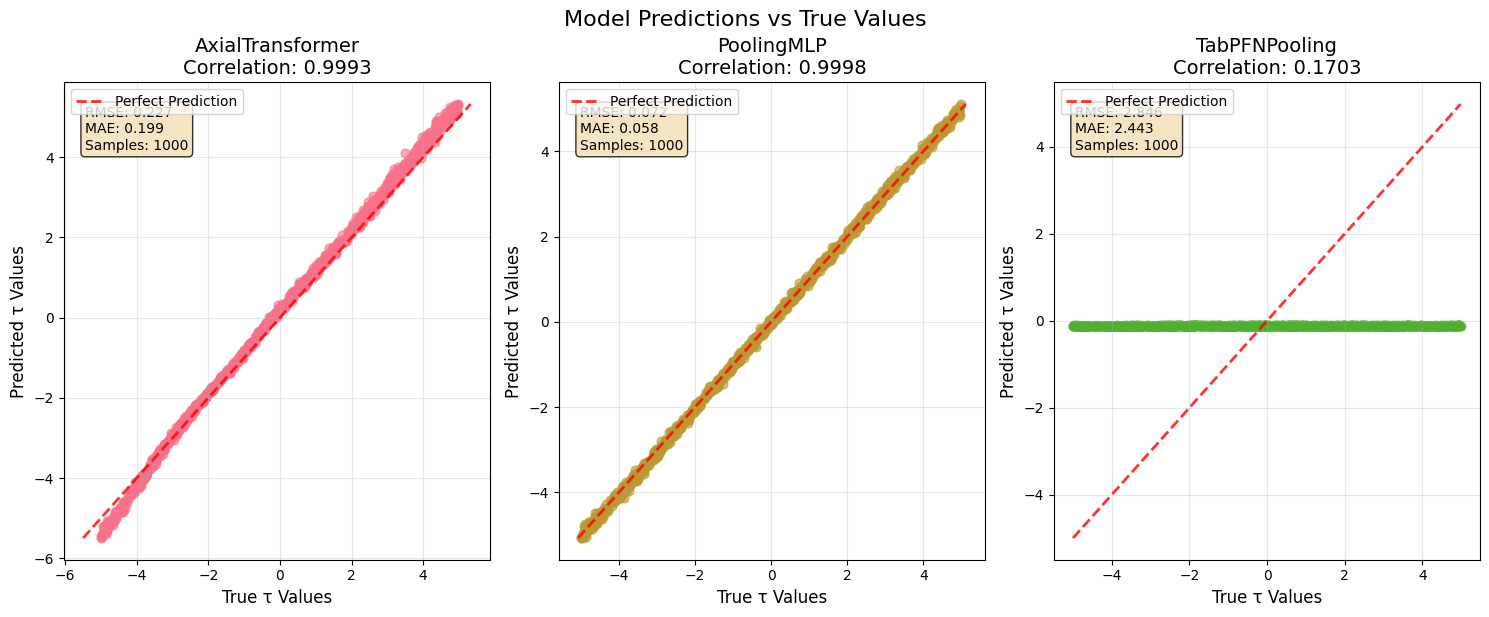

In [62]:
# Plot predictions vs true values
plot_predictions_vs_true([axial_results, mlp_results, tabpfn_results])

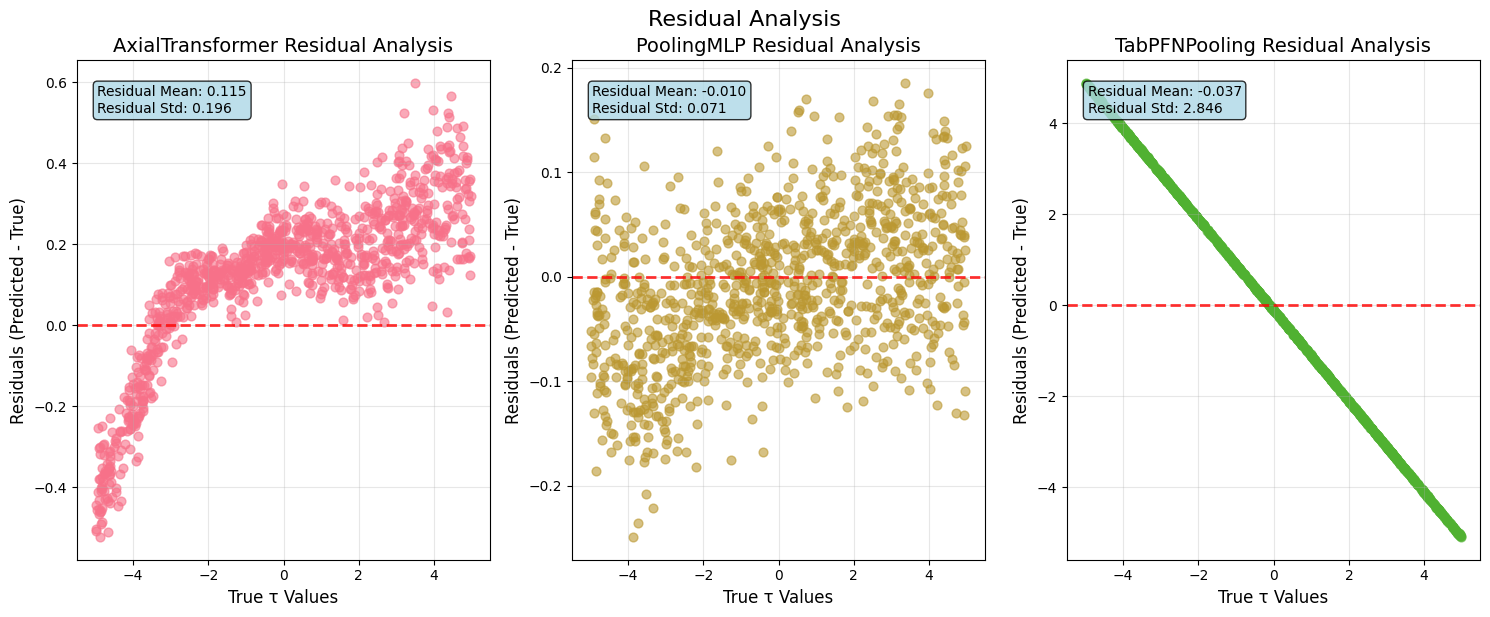

In [63]:
# Plot residuals
plot_residuals([axial_results, mlp_results, tabpfn_results])

## Model Performance Comparison

In [64]:
def plot_model_comparison(results_list: List[Dict]):
    """
    Plot model performance comparison
    """
    metrics = ['mse', 'mae', 'rmse']
    model_names = [r['model_name'] for r in results_list]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # MSE, MAE, RMSE comparison
    for i, metric in enumerate(metrics):
        values = [r[metric] for r in results_list]
        colors = [f'C{j}' for j in range(len(results_list))]
        bars = axes[i].bar(model_names, values, alpha=0.7, color=colors)
        
        # Add value labels
        for bar, value in zip(bars, values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                        f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
        
        axes[i].set_ylabel(metric.upper(), fontsize=12)
        axes[i].set_title(f'Model {metric.upper()} Comparison', fontsize=14)
        axes[i].grid(True, alpha=0.3)
    
    # Correlation comparison
    correlations = [r['correlation'] for r in results_list]
    colors = [f'C{j}' for j in range(len(results_list))]
    bars = axes[3].bar(model_names, correlations, alpha=0.7, color=colors)
    
    for bar, corr in zip(bars, correlations):
        axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{corr:.4f}', ha='center', va='bottom', fontweight='bold')
    
    axes[3].set_ylabel('Correlation Coefficient', fontsize=12)
    axes[3].set_title('Model Correlation Comparison', fontsize=14)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Model comparison visualization function defined")

Model comparison visualization function defined


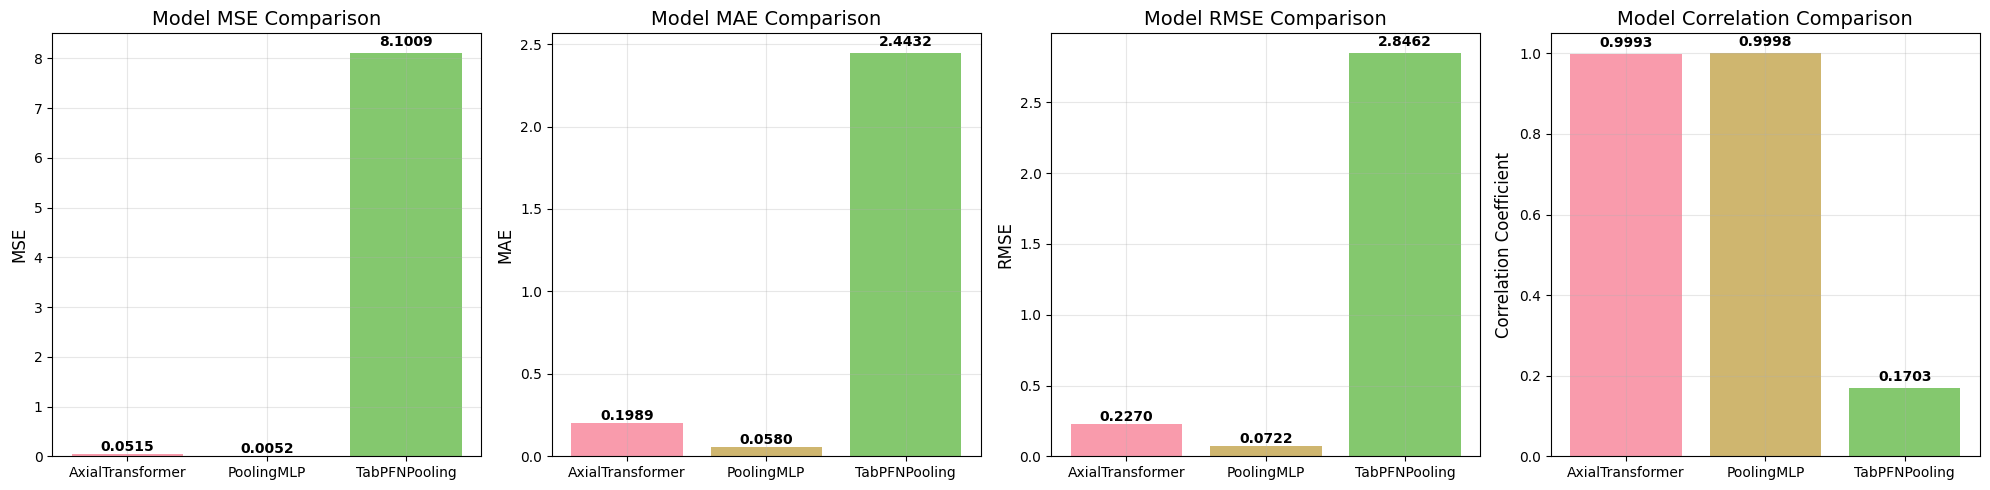

In [65]:
# Plot model comparison
plot_model_comparison([axial_results, mlp_results, tabpfn_results])

## Range Tau Sensitivity Analysis

In [66]:
def analyze_tau_range_performance(results_list: List[Dict]):
    """
    Analyze model performance across different tau ranges
    """
    # Define tau intervals
    tau_bins = [(-5, -3), (-3, -1), (-1, 1), (1, 3), (3, 5)]
    bin_labels = [f'[{b[0]}, {b[1]})' for b in tau_bins]
    
    n_models = len(results_list)
    fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 12))
    
    if n_models == 1:
        axes = axes.reshape(-1, 1)
    
    for model_idx, results in enumerate(results_list):
        y_pred = results['predictions']
        y_true = results['true_values']
        model_name = results['model_name']
        
        # Calculate performance for each interval
        bin_mse = []
        bin_mae = []
        bin_counts = []
        
        for bin_min, bin_max in tau_bins:
            mask = (y_true >= bin_min) & (y_true < bin_max)
            if np.sum(mask) > 0:
                y_true_bin = y_true[mask]
                y_pred_bin = y_pred[mask]
                
                mse = np.mean((y_pred_bin - y_true_bin) ** 2)
                mae = np.mean(np.abs(y_pred_bin - y_true_bin))
                
                bin_mse.append(mse)
                bin_mae.append(mae)
                bin_counts.append(len(y_true_bin))
            else:
                bin_mse.append(0)
                bin_mae.append(0)
                bin_counts.append(0)
        
        # Plot MSE
        bars1 = axes[0, model_idx].bar(bin_labels, bin_mse, alpha=0.7, color=f'C{model_idx}')
        axes[0, model_idx].set_title(f'{model_name} - MSE by τ Range', fontsize=14)
        axes[0, model_idx].set_ylabel('MSE', fontsize=12)
        axes[0, model_idx].tick_params(axis='x', rotation=45)
        axes[0, model_idx].grid(True, alpha=0.3)
        
        # Plot MAE
        bars2 = axes[1, model_idx].bar(bin_labels, bin_mae, alpha=0.7, color=f'C{model_idx}', 
                                       edgecolor='black', linewidth=0.5)
        axes[1, model_idx].set_title(f'{model_name} - MAE by τ Range', fontsize=14)
        axes[1, model_idx].set_ylabel('MAE', fontsize=12)
        axes[1, model_idx].tick_params(axis='x', rotation=45)
        axes[1, model_idx].grid(True, alpha=0.3)
        
        # Add sample count labels
        for i, (mse, mae, count) in enumerate(zip(bin_mse, bin_mae, bin_counts)):
            if count > 0:
                axes[0, model_idx].text(i, mse + mse*0.05, f'n={count}', 
                                      ha='center', va='bottom', fontsize=9, fontweight='bold')
                axes[1, model_idx].text(i, mae + mae*0.05, f'n={count}', 
                                      ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*80)
    print("RANGE TAU SENSITIVITY ANALYSIS RESULTS")
    print("="*80)
    
    for results in results_list:
        y_pred = results['predictions']
        y_true = results['true_values']
        model_name = results['model_name']
        print(f"\n{model_name}:")
        print("-" * 50)
        
        for i, (bin_min, bin_max) in enumerate(tau_bins):
            mask = (y_true >= bin_min) & (y_true < bin_max)
            if np.sum(mask) > 0:
                y_true_bin = y_true[mask]
                y_pred_bin = y_pred[mask]
                
                mse = np.mean((y_pred_bin - y_true_bin) ** 2)
                mae = np.mean(np.abs(y_pred_bin - y_true_bin))
                rmse = np.sqrt(mse)
                
                try:
                    corr = np.corrcoef(y_pred_bin, y_true_bin)[0, 1]
                    if np.isnan(corr):
                        corr = 0.0
                except:
                    corr = 0.0
                
                print(f"   Range [{bin_min:2.0f}, {bin_max:2.0f}): MSE={mse:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f} | Corr={corr:.4f} | Samples={len(y_true_bin):3d}")
            else:
                print(f"   Range [{bin_min:2.0f}, {bin_max:2.0f}): No samples")

print("Range Tau sensitivity analysis function defined")

Range Tau sensitivity analysis function defined


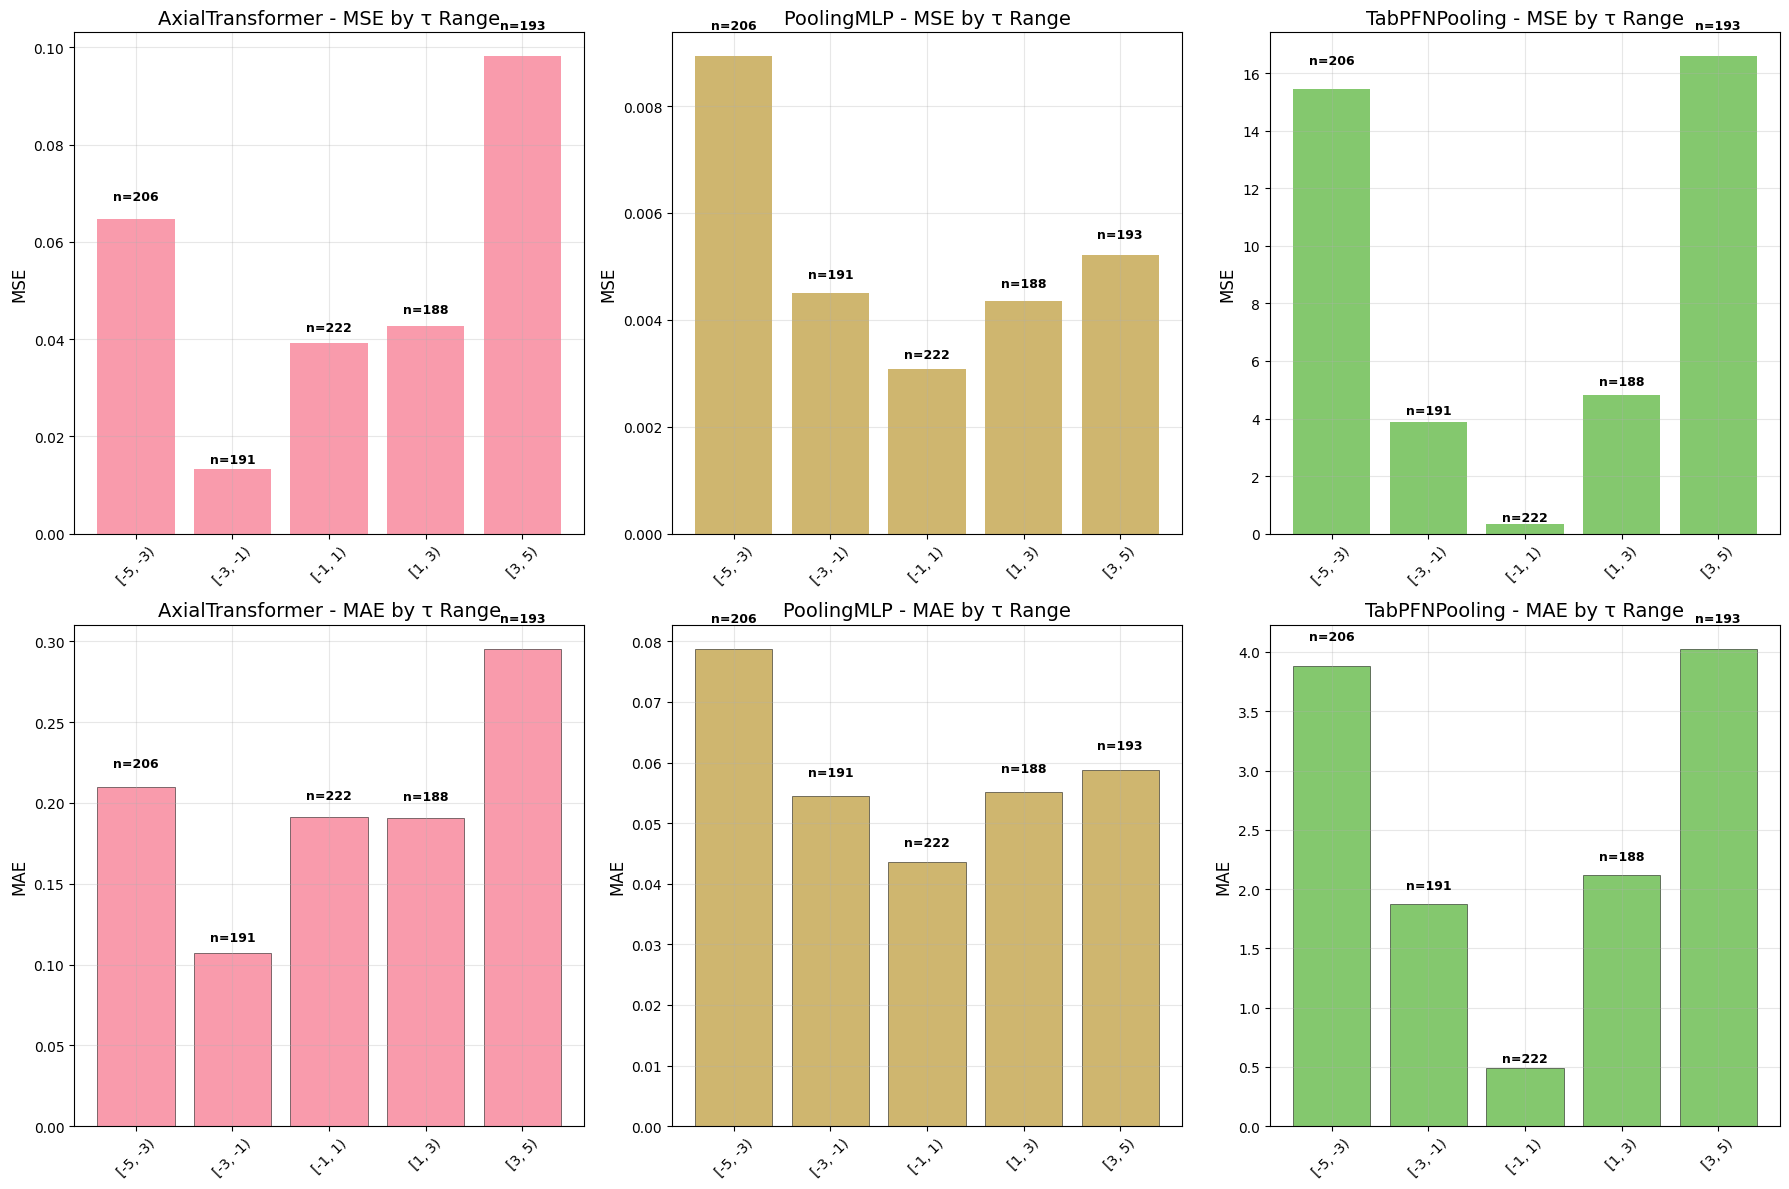


RANGE TAU SENSITIVITY ANALYSIS RESULTS

AxialTransformer:
--------------------------------------------------
   Range [-5, -3): MSE=0.0648 | MAE=0.2097 | RMSE=0.2546 | Corr=0.9966 | Samples=206
   Range [-3, -1): MSE=0.0133 | MAE=0.1072 | RMSE=0.1151 | Corr=0.9974 | Samples=191
   Range [-1,  1): MSE=0.0391 | MAE=0.1910 | RMSE=0.1978 | Corr=0.9963 | Samples=222
   Range [ 1,  3): MSE=0.0427 | MAE=0.1907 | RMSE=0.2066 | Corr=0.9915 | Samples=188
   Range [ 3,  5): MSE=0.0982 | MAE=0.2954 | RMSE=0.3134 | Corr=0.9866 | Samples=193

PoolingMLP:
--------------------------------------------------
   Range [-5, -3): MSE=0.0089 | MAE=0.0788 | RMSE=0.0945 | Corr=0.9926 | Samples=206
   Range [-3, -1): MSE=0.0045 | MAE=0.0545 | RMSE=0.0670 | Corr=0.9960 | Samples=191
   Range [-1,  1): MSE=0.0031 | MAE=0.0436 | RMSE=0.0555 | Corr=0.9954 | Samples=222
   Range [ 1,  3): MSE=0.0043 | MAE=0.0551 | RMSE=0.0659 | Corr=0.9946 | Samples=188
   Range [ 3,  5): MSE=0.0052 | MAE=0.0588 | RMSE=0.0722 | Co

In [67]:
# Perform Range Tau sensitivity analysis
analyze_tau_range_performance([axial_results, mlp_results, tabpfn_results])

## Bias-Variance Decomposition

### Bias-Variance Decomposition
We decompose the mean squared error using errors e = y_pred − y_true:

MSE = E[e^2] = Var(e) + (E[e])^2 = Variance + Bias^2.

Below we compute Bias, Bias^2, Variance, and MSE for each model.


           Model      Bias   Bias^2  Variance      MSE
AxialTransformer  0.114848 0.013190  0.038354 0.051544
      PoolingMLP -0.010317 0.000106  0.005100 0.005207
   TabPFNPooling -0.036560 0.001337  8.099524 8.100860


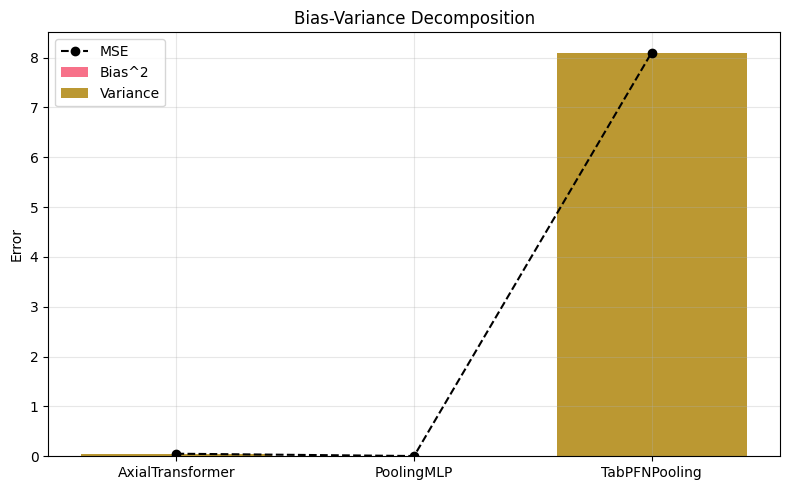

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare per-model errors
def bias_variance_summary(results_list: List[Dict]) -> pd.DataFrame:
    rows = []
    for r in results_list:
        y_pred = np.asarray(r['predictions'])
        y_true = np.asarray(r['true_values'])
        err = y_pred - y_true
        bias = err.mean()
        var = err.var()
        mse = (err**2).mean()
        rows.append({
            'Model': r['model_name'],
            'Bias': bias,
            'Bias^2': bias**2,
            'Variance': var,
            'MSE': mse
        })
    return pd.DataFrame(rows)

bv_df = bias_variance_summary([axial_results, mlp_results, tabpfn_results])
print(bv_df.to_string(index=False))

# Plot stacked Bias^2 + Variance vs MSE for a visual check
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
indices = np.arange(len(bv_df))
ax.bar(indices, bv_df['Bias^2'], label='Bias^2')
ax.bar(indices, bv_df['Variance'], bottom=bv_df['Bias^2'], label='Variance')
ax.plot(indices, bv_df['MSE'], 'ko--', label='MSE')
ax.set_xticks(indices)
ax.set_xticklabels(bv_df['Model'], rotation=0)
ax.set_ylabel('Error')
ax.set_title('Bias-Variance Decomposition')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [69]:
def print_comprehensive_summary(results_list: List[Dict]):
    """
    Print comprehensive model evaluation summary
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE MODEL EVALUATION SUMMARY")
    print("="*80)
    
    # Create comparison table
    summary_data = []
    for results in results_list:
        pred_min, pred_max = results['predictions'].min(), results['predictions'].max()
        true_min, true_max = results['true_values'].min(), results['true_values'].max()
        
        summary_data.append({
            'Model': results['model_name'],
            'MSE': f"{results['mse']:.4f}",
            'MAE': f"{results['mae']:.4f}",
            'RMSE': f"{results['rmse']:.4f}",
            'Correlation': f"{results['correlation']:.4f}",
            'Pred_Range': f"[{pred_min:.2f}, {pred_max:.2f}]",
            'True_Range': f"[{true_min:.2f}, {true_max:.2f}]",
            'Samples': len(results['predictions'])
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\nPerformance Metrics Comparison:")
    print("-" * 80)
    print(summary_df.to_string(index=False))
    
    # Identify best models
    correlations = [r['correlation'] for r in results_list]
    mse_values = [r['mse'] for r in results_list]
    mae_values = [r['mae'] for r in results_list]
    
    best_corr_idx = np.argmax(correlations)
    best_mse_idx = np.argmin(mse_values)
    best_mae_idx = np.argmin(mae_values)
    
    print("\nBest Performing Models:")
    print("-" * 30)
    print(f"Highest Correlation: {results_list[best_corr_idx]['model_name']} ({correlations[best_corr_idx]:.4f})")
    print(f"Lowest MSE: {results_list[best_mse_idx]['model_name']} ({mse_values[best_mse_idx]:.4f})")
    print(f"Lowest MAE: {results_list[best_mae_idx]['model_name']} ({mae_values[best_mae_idx]:.4f})")
    
    print("\nKey Observations and Insights:")
    print("-" * 30)
    print("1. Experimental Setup:")
    print("   - Both models trained to predict τ in range [-5, 5]")
    print("   - Dataset: Lennon7 with 7 instrumental variables")
    print("   - Input features: T (treatment), Y (outcome), Z1-Z7 (instruments)")
    
    print("\n2. Model Architecture Comparison:")
    print("   - AxialTransformer: Uses axial attention across sample and feature dimensions")
    print("   - PoolingMLP: Uses pooling operations to aggregate sequences into fixed representations")
    
    print("\n3. Performance Analysis:")
    if len(results_list) >= 2:
        axial_idx = 0 if 'Axial' in results_list[0]['model_name'] else 1
        mlp_idx = 1 - axial_idx
        
        corr_diff = correlations[axial_idx] - correlations[mlp_idx]
        mse_diff = mse_values[axial_idx] - mse_values[mlp_idx]
        
        if abs(corr_diff) > 0.05:
            better_corr = "AxialTransformer" if corr_diff > 0 else "PoolingMLP"
            print(f"   - {better_corr} shows better correlation performance (diff: {abs(corr_diff):.4f})")
        else:
            print("   - Both models show similar correlation performance")
            
        if abs(mse_diff) > 0.1:
            better_mse = "PoolingMLP" if mse_diff > 0 else "AxialTransformer"
            print(f"   - {better_mse} shows better MSE performance")
        else:
            print("   - Both models show similar MSE performance")
    
    print("\n4. Causal Inference Perspective:")
    print("   - Treatment effect prediction is core to causal inference")
    print("   - Models must identify causal relationships, not just correlations")
    print("   - Range Tau analysis reveals performance differences across effect sizes")
    
    print("\n5. Practical Recommendations:")
    best_overall = results_list[best_corr_idx]['model_name']
    print(f"   - Recommend {best_overall} for this type of causal inference task")
    print("   - Consider ensemble methods combining both models")
    print("   - Need more training data and longer training for better performance")
    
    print("" + "="*80)

print("Comprehensive summary function defined")

Comprehensive summary function defined


In [70]:
# Print comprehensive summary
print_comprehensive_summary([axial_results, mlp_results, tabpfn_results])


COMPREHENSIVE MODEL EVALUATION SUMMARY

Performance Metrics Comparison:
--------------------------------------------------------------------------------
           Model    MSE    MAE   RMSE Correlation     Pred_Range    True_Range  Samples
AxialTransformer 0.0515 0.1989 0.2270      0.9993  [-5.50, 5.33] [-5.00, 4.99]     1000
      PoolingMLP 0.0052 0.0580 0.0722      0.9998  [-5.07, 5.11] [-5.00, 4.99]     1000
   TabPFNPooling 8.1009 2.4432 2.8462      0.1703 [-0.13, -0.09] [-5.00, 4.99]     1000

Best Performing Models:
------------------------------
Highest Correlation: PoolingMLP (0.9998)
Lowest MSE: PoolingMLP (0.0052)
Lowest MAE: PoolingMLP (0.0580)

Key Observations and Insights:
------------------------------
1. Experimental Setup:
   - Both models trained to predict τ in range [-5, 5]
   - Dataset: Lennon7 with 7 instrumental variables
   - Input features: T (treatment), Y (outcome), Z1-Z7 (instruments)

2. Model Architecture Comparison:
   - AxialTransformer: Uses axial at

## Save Experiment Results

In [71]:
# Save evaluation results to file
import json
from datetime import datetime
import os

# Prepare results for saving
results_to_save = {
    'experiment_info': {
        'timestamp': datetime.now().isoformat(),
        'dataset': 'lennon7-range-tau-10k',
        'n_test_samples': len(y_true),
        'tau_range': [float(y_true.min()), float(y_true.max())],
        'tau_mean': float(y_true.mean()),
        'tau_std': float(y_true.std())
    },
    'model_configs': {
        'AxialTransformer': axial_transformer_config,
        'PoolingMLP': pooling_mlp_config,
        'TabPFNPooling': tabpfn_pooling_config
    },
    'evaluation_results': {}
}

# Add evaluation results for each model
for results in [axial_results, mlp_results, tabpfn_results]:
    model_name = results['model_name']
    results_to_save['evaluation_results'][model_name] = {
        'mse': float(results['mse']),
        'mae': float(results['mae']),
        'rmse': float(results['rmse']),
        'correlation': float(results['correlation']),
        'prediction_range': [float(results['predictions'].min()), 
                           float(results['predictions'].max())],
        'prediction_mean': float(results['predictions'].mean()),
        'prediction_std': float(results['predictions'].std())
    }

# Create results directory
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

# Save results to JSON file
output_file = os.path.join(results_dir, 'range_tau_evaluation_results.json')

try:
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(results_to_save, f, indent=2, ensure_ascii=False)
    
    print(f"\nEvaluation results saved to: {output_file}")
    print(f"File size: {os.path.getsize(output_file)} bytes")
    
except Exception as e:
    print(f"Failed to save results: {e}")

print("\n" + "="*80)
print("EXPERIMENT COMPLETED!")
print("="*80)
print("This notebook provides comprehensive testing and visualization analysis of AxialTransformer, PoolingMLP and TabPFNPooling models:")
print("\nMain Features:")
print("✓ Model loading and configuration")
print("✓ Data preprocessing and synthetic data generation")
print("✓ Model performance evaluation (MSE, MAE, RMSE, correlation)")
print("✓ Predictions vs true values visualization")
print("✓ Residual analysis")
print("✓ Range Tau sensitivity analysis")
print("✓ Comprehensive performance comparison")
print("✓ Results saving")
print("\nYou can customize:")
print("- Model configuration parameters")
print("- Test data sample size")
print("- Add more evaluation metrics")
print("- Customize visualization styles")
print("- Extend Range Tau analysis intervals")
print("\n" + "="*80)


Evaluation results saved to: ../results/range_tau_evaluation_results.json
File size: 2126 bytes

EXPERIMENT COMPLETED!
This notebook provides comprehensive testing and visualization analysis of AxialTransformer, PoolingMLP and TabPFNPooling models:

Main Features:
✓ Model loading and configuration
✓ Data preprocessing and synthetic data generation
✓ Model performance evaluation (MSE, MAE, RMSE, correlation)
✓ Predictions vs true values visualization
✓ Residual analysis
✓ Range Tau sensitivity analysis
✓ Comprehensive performance comparison
✓ Results saving

You can customize:
- Model configuration parameters
- Test data sample size
- Add more evaluation metrics
- Customize visualization styles
- Extend Range Tau analysis intervals

